In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from warnings import filterwarnings
filterwarnings("ignore")

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [5]:
data_from_2019_to_2020 = pd.read_csv("../data/data_by_2019-2020.csv") 
data_from_2019_to_2020.columns

Index(['Unnamed: 0', 'Year', 'Decimal Day', 'Hour', 'Bz_GSM', 'By_GSM',
       'Bx_GSE', 'Kp', 'f10.7', 'AL', 'AU', 'T_proton', 'Np_density',
       'V_plasma', 'V_Long_GSE', 'V_Lat_GSE', 'Dst', 'AE'],
      dtype='str')

In [11]:
target_column = 'Dst' 
data = data_from_2019_to_2020.copy()
train_data = data[data['Year'] == 2019] 
test_data = data[data['Year'] == 2020]  

In [16]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data[[target_column]])
test_scaled = scaler.transform(test_data[[target_column]])

In [17]:
class GeomagneticDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        X,
        y,
        X_window_size: int,
        y_window_size: int,
        stride: int = 1,
    ):
        self.X = torch.FloatTensor(X) if not isinstance(X, torch.Tensor) else X
        self.y = torch.FloatTensor(y) if not isinstance(y, torch.Tensor) else y
        self.X_window_size = X_window_size
        self.y_window_size = y_window_size
        self.stride = stride

        assert len(self.X) == len(self.y), "X and y must have same length"

        total_window = X_window_size + y_window_size
        self.num_samples = (len(self.X) - total_window) // stride + 1
        assert self.num_samples > 0, "Not enough data for windows"

    def __len__(self) -> int:
        return self.num_samples

    def __getitem__(self, index):
        start_idx = index * self.stride

        x_end_idx = start_idx + self.X_window_size
        x_window = self.X[start_idx:x_end_idx]

        y_start_idx = x_end_idx
        y_end_idx = y_start_idx + self.y_window_size
        y_window = self.y[y_start_idx:y_end_idx]  

        return x_window, y_window

In [20]:
X_window_size = 24 
y_window_size = 1  
stride = 1


train_dataset = GeomagneticDataset(
    X=train_scaled,
    y=train_scaled,
    X_window_size=X_window_size,
    y_window_size=y_window_size,
    stride=stride
)

test_dataset = GeomagneticDataset(
    X=test_scaled,
    y=test_scaled,
    X_window_size=X_window_size,
    y_window_size=y_window_size,
    stride=stride
)

batch_size = 32
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
class Regressor(nn.Module):
    def __init__(self, n_features, rnn_hs, rnn_nl, rnn_do):
        super().__init__()
        self._rnn1 = nn.LSTM(
            input_size=n_features,
            hidden_size=rnn_hs,
            num_layers=1,
            batch_first=True,
        )
        self._dropout1 = nn.Dropout(rnn_do)
        
        self._rnn2 = nn.LSTM(
            input_size=rnn_hs,
            hidden_size=rnn_hs,
            num_layers=1,
            batch_first=True,
        )
        self._dropout2 = nn.Dropout(rnn_do)
        
        self._rnn3 = nn.LSTM(
            input_size=rnn_hs,
            hidden_size=rnn_hs,
            num_layers=1,
            batch_first=True,
        )
        self._dropout3 = nn.Dropout(rnn_do)
        
        self._rnn4 = nn.LSTM(
            input_size=rnn_hs,
            hidden_size=rnn_hs,
            num_layers=1,
            batch_first=True,
        )
        self._dropout4 = nn.Dropout(rnn_do)
        
        self._head = nn.Linear(rnn_hs, 1)
    
    def forward(self, x):
        x, _ = self._rnn1(x)
        x = self._dropout1(x)
        
        x, _ = self._rnn2(x)
        x = self._dropout2(x)
        
        x, _ = self._rnn3(x)
        x = self._dropout3(x)
        
        x, (_, _) = self._rnn4(x)
        x = self._dropout4(x)
        x = x[:, -1, :]  
        
        return self._head(x)

In [21]:
model = Regressor(
    n_features=1,      
    rnn_hs=50,        
    rnn_nl=4,         
    rnn_do=0.2         
)
optimizer = optim.RMSprop(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [ ]:
epochs = 50
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_X)
        target = batch_y[:, -1, :]  

        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], LF = {avg_loss:.6f}")

In [23]:
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        output = model(batch_X)
        target = batch_y[:, -1, :]
        
        predictions.extend(output.numpy().flatten())
        actuals.extend(target.numpy().flatten())
predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
actuals = scaler.inverse_transform(np.array(actuals).reshape(-1, 1))
rmse = np.sqrt(np.mean((predictions - actuals) ** 2))

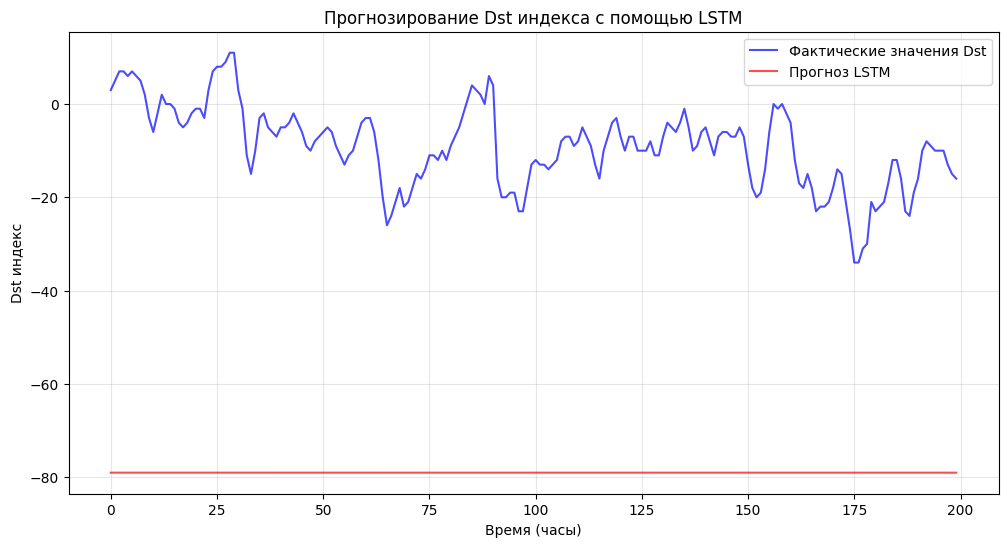

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(actuals[:200], label='Фактические значения Dst', color='blue', alpha=0.7)
plt.plot(predictions[:200], label='Прогноз LSTM', color='red', alpha=0.7)
plt.title('Прогнозирование Dst индекса с помощью LSTM')
plt.xlabel('Время (часы)')
plt.ylabel('Dst индекс')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()